## Group Name: Random_Group

Members
Tlotliso Ledwaba
Lucky

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
data = pd.read_csv("dataset.csv")

## Class Distribution

Before any modelling can begin, it is essential to understand how balanced or imbalanced the target variable is. The chart below shows the count of fraudulent versus legitimate transactions in the dataset, plotted on a logarithmic scale to make the fraud class visible at all, given how small it is relative to legitimate transactions.

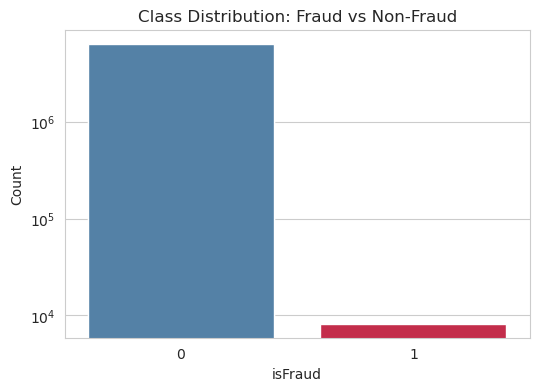

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=data)
sns.countplot(x='isFraud', data=data, palette={'0': 'steelblue', '1': 'crimson'})
plt.title('Class Distribution: Fraud vs Non-Fraud')
plt.xlabel('isFraud')
plt.ylabel('Count')
plt.yscale('log')
plt.show()

Fraudulent transactions make up only a small fraction of the dataset. This severe class imbalance means that a model predicting every transaction as legitimate would still achieve extremely high accuracy while catching zero fraud cases. For this reason, accuracy is not a suitable metric for this problem, precision, recall, F1-score, and PR-AUC will be used instead throughout this analysis.

In [4]:
print(data['isFraud'].value_counts(normalize=True) * 100)

isFraud
0   99.87
1    0.13
Name: proportion, dtype: float64


## Fraud by Transaction Type

Not all transaction types carry equal fraud risk. The chart below breaks down the number of fraudulent transactions by transaction type, revealing which categories require closer scrutiny and which can largely be excluded from fraud-focused feature engineering.

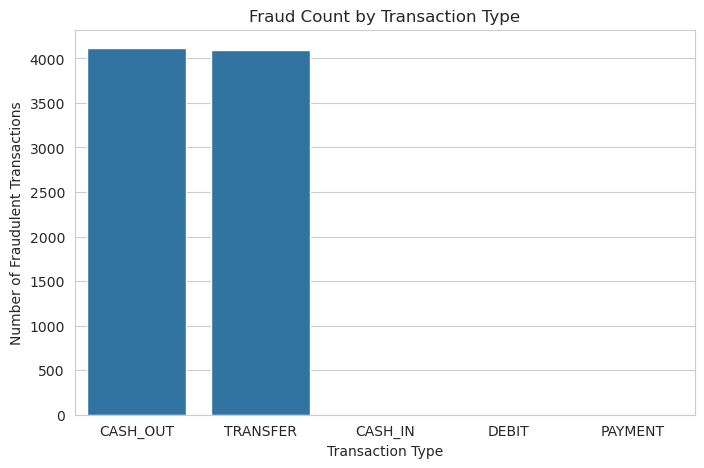

In [5]:
plt.figure(figsize=(8,5))
fraud_by_type = data.groupby('type')['isFraud'].sum().sort_values(ascending=False)
sns.barplot(x=fraud_by_type.index, y=fraud_by_type.values)
plt.title('Fraud Count by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

The results confirm that fraudulent transactions occur exclusively within TRANSFER and CASH_OUT transaction types. PAYMENT, CASH_IN, and DEBIT transactions show no fraud cases in this dataset. This finding directly shapes the feature engineering approach that follows, with particular attention paid to transactions where funds leave an account through these two channels.

## Transaction Amount Analysis

Transaction amounts in this dataset vary widely, ranging from small everyday payments to multi-million transfers within the same column. The scatterplot below shows individual transaction amounts over time, separated by fraud status, making it possible to see how amounts are spread across both classes, including outliers, without summarising them into an average.

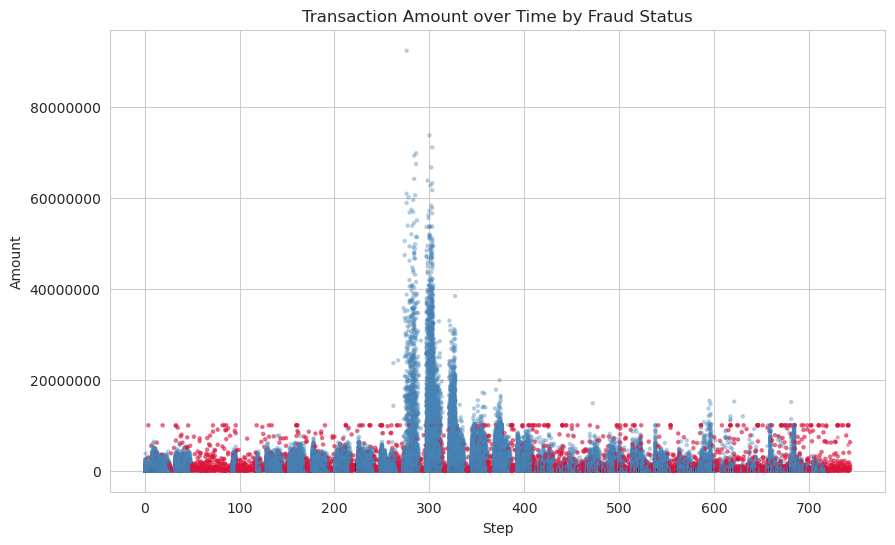

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(data['step'], data['amount'], c=data['isFraud'].map({0: 'steelblue', 1: 'crimson'}),
            alpha=0.3, s=5)
plt.title('Transaction Amount over Time by Fraud Status')
plt.xlabel('Step')
plt.ylabel('Amount')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Fraud Over Time

Fraud transactions were found to be clustered in the dataset rather than spread evenly throughout. The chart below shows the number of fraudulent transactions at each simulation step, revealing whether fraud tends to concentrate at particular points in time.

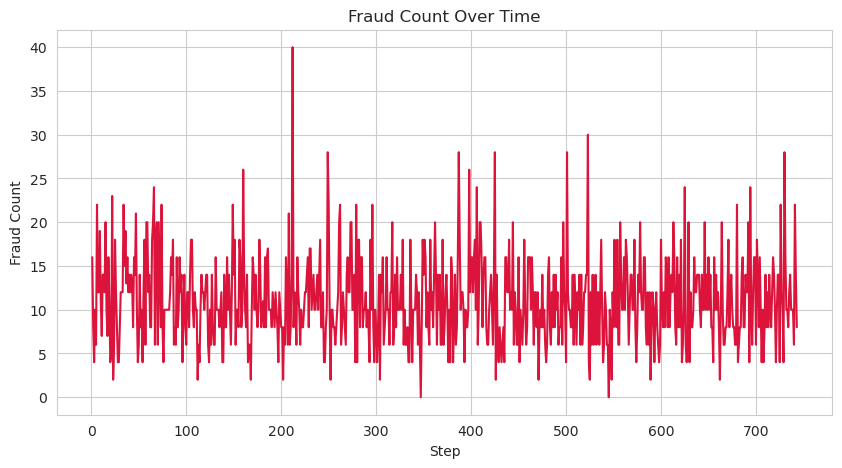

In [7]:
fraud_by_step = data.groupby('step')['isFraud'].sum()
plt.figure(figsize=(10,5))
plt.plot(fraud_by_step.index, fraud_by_step.values, color='crimson')
plt.title('Fraud Count Over Time')
plt.xlabel('Step')
plt.ylabel('Fraud Count')
plt.show()

## Feature Engineering

Raw transaction data alone does not clearly expose fraud patterns. This section constructs additional features, derived from relationships between existing columns, that make fraud behaviour visible to a model. Features are grouped into two categories: mathematical features, which check whether account balances behaved as expected, and behavioural features, which look at patterns across multiple transactions.

### Mathematical Features

This step constructs the core mathematical features used to detect fraud. Transaction type is one-hot encoded so the model can use it without assuming a false order between categories. `errorBalanceOrig` checks whether the sender's balance changed by the exact amount the transaction should have caused, accounting for the fact that CASH_IN transactions add money while all other types remove it. `errorBalanceDest` performs the same check on the receiving account, flagging cases where funds did not arrive as expected. `orig_balance_zeroed` flags accounts that were emptied completely, and `full_drain_transfer` combines transaction type, exact balance match, and full drain into a single, stricter indicator, based on the pattern identified during data exploration where fraudulent transactions consistently drained the sender's account entirely. The fraud rate printed below shows how strongly this combined indicator correlates with actual fraud.

In [8]:
data = pd.get_dummies(data, columns=['type'], prefix='type')

data['errorBalanceOrig'] = np.where(
    data['type_CASH_IN'] == 1,
    data['newbalanceOrig'] - (data['oldbalanceOrg'] + data['amount']),
    data['newbalanceOrig'] - (data['oldbalanceOrg'] - data['amount'])
)

data['errorBalanceDest'] = data['newbalanceDest'] - (data['oldbalanceDest'] + data['amount'])

data['orig_balance_zeroed'] = (data['newbalanceOrig'] == 0).astype(int)

data['full_drain_transfer'] = (
    ((data['type_TRANSFER'] == 1) | (data['type_CASH_OUT'] == 1)) &
    (data['oldbalanceOrg'] == data['amount']) &
    (data['newbalanceOrig'] == 0)
).astype(int)

data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'errorBalanceOrig',
      'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest',
      'orig_balance_zeroed', 'full_drain_transfer', 'isFraud']].head(20)

,amount,oldbalanceOrg,newbalanceOrig,errorBalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceDest,orig_balance_zeroed,full_drain_transfer,isFraud
0,9839.64,170136.00,160296.36,0.00,0.00,0.00,-9839.64,0,0,0
1,1864.28,21249.00,19384.72,0.00,0.00,0.00,-1864.28,0,0,0
2,181.00,181.00,0.00,0.00,0.00,0.00,-181.00,1,1,1
3,181.00,181.00,0.00,0.00,21182.00,0.00,-21363.00,1,1,1
4,11668.14,41554.00,29885.86,0.00,0.00,0.00,-11668.14,0,0,0
5,7817.71,53860.00,46042.29,0.00,0.00,0.00,-7817.71,0,0,0
6,7107.77,183195.00,176087.23,0.00,0.00,0.00,-7107.77,0,0,0
7,7861.64,176087.23,168225.59,0.00,0.00,0.00,-7861.64,0,0,0
8,4024.36,2671.00,0.00,1353.36,0.00,0.00,-4024.36,1,0,0
9,5337.77,41720.00,36382.23,0.00,41898.00,40348.79,-6886.98,0,0,0


### Behavioural Features

Unlike the mathematical features, which check a single transaction in isolation, behavioural features look at patterns across multiple transactions. This feature counts how many distinct sending accounts have sent money to a given destination account. A legitimate personal account typically receives from a small, familiar set of senders, while an account acting as a collection point for fraud may receive from many different, unrelated senders. The values printed below compare the average sender count for fraudulent versus legitimate transactions, indicating whether this pattern holds in this dataset.

In [9]:
data['dest_sender_count'] = data.groupby('nameDest')['nameOrig'].transform('nunique')

data.groupby('isFraud')['dest_sender_count'].mean()

isFraud
0   11.20
1    8.10
Name: dest_sender_count, dtype: float64

This feature checks whether a transaction's amount and step match a corresponding transaction of the opposite type (a TRANSFER matched with a CASH_OUT, or vice versa) occurring in the same step. This reflects the actual pattern identified during investigation, fraudulent activity in this dataset consistently produces a matched TRANSFER/CASH_OUT pair sharing the same amount and step, rather than a literal chain through a single shared account.

In [10]:
transfers = data[data['type_TRANSFER'] == 1][['step', 'amount']].copy()
cashouts = data[data['type_CASH_OUT'] == 1][['step', 'amount']].copy()

paired = transfers.merge(cashouts, on=['step', 'amount'])
print(paired.shape)

paired_keys = set(zip(paired['step'], paired['amount']))

data['is_paired_transaction'] = data.apply(
    lambda row: (row['step'], row['amount']) in paired_keys
    if (row['type_TRANSFER'] == 1 or row['type_CASH_OUT'] == 1) else False,
    axis=1
).astype(int)

data.groupby('is_paired_transaction')['isFraud'].mean()

(5142, 2)


is_paired_transaction
0   0.00
1   0.90
Name: isFraud, dtype: float64

In [11]:
data['step_amount_key'] = list(zip(data['step'], data['amount']))

data['is_paired_transaction'] = (
    data['step_amount_key'].isin(paired_keys) &
    ((data['type_TRANSFER'] == 1) | (data['type_CASH_OUT'] == 1))
).astype(int)

data.drop(columns=['step_amount_key'], inplace=True)

data.groupby('is_paired_transaction')['isFraud'].mean()

is_paired_transaction
0   0.00
1   0.90
Name: isFraud, dtype: float64

In [12]:
recall = data[data['isFraud'] == 1]['is_paired_transaction'].mean()
total_fraud = data['isFraud'].sum()
caught = data[(data['isFraud'] == 1) & (data['is_paired_transaction'] == 1)].shape[0]

print(f"Out of {total_fraud} fraud transactions, this feature catches {caught} of them.")
print(f"That's {recall:.2%} of all fraud cases.")

Out of 8213 fraud transactions, this feature catches 8153 of them.
That's 99.27% of all fraud cases.


### Train/Test Split and Class Balancing

The dataset is split into training and test sets before any resampling occurs, using stratification to preserve the fraud ratio in both sets. SMOTE is then applied only to the training data to address the severe class imbalance, generating synthetic fraud examples for the model to learn from. The test set remains untouched, preserving the original real-world fraud ratio, since it will be used to evaluate how the model performs on unseen, realistic data. Both the resampled training set and the original test set are saved separately for use in model training and evaluation.

In [14]:

# 1. Drop identifier and leakage-risk columns from the feature set
features_to_drop = ['nameOrig', 'nameDest', 'step', 'isFlaggedFraud', 'isFraud']

X = data.drop(columns=features_to_drop)
y = data['isFraud']

# 2. Train/test split, stratified given the severe imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. SMOTE, training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())

# 4. Save the resampled training set and the untouched test set as new files
train_resampled = X_train_sm.copy()
train_resampled['isFraud'] = y_train_sm
train_resampled.to_csv('train_resampled.csv', index=False)

test_set = X_test.copy()
test_set['isFraud'] = y_test
test_set.to_csv('test_set.csv', index=False)

print("Saved train_resampled.csv and test_set.csv")

Before SMOTE: {0: 5083526, 1: 6570}
After SMOTE:  {0: 5083526, 1: 5083526}
Saved train_resampled.csv and test_set.csv


### Comparing Key Fraud Indicators

Two engineered features stood out as particularly strong indicators of fraud, a full account drain and a matched TRANSFER/CASH_OUT pair at the same amount and step. The chart below compares the fraud rate associated with each, showing which indicator more strongly separates fraudulent from legitimate transactions.

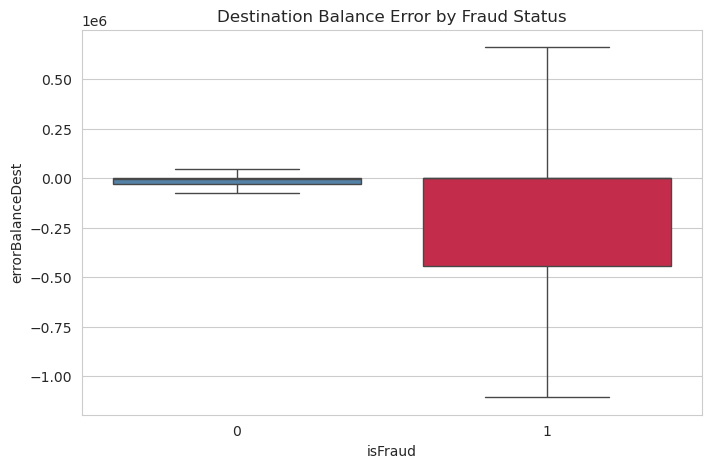

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='isFraud', y='errorBalanceDest', data=data, showfliers=False,
            palette={"0": 'steelblue', "1": 'crimson'})
plt.title('Destination Balance Error by Fraud Status')
plt.show()

## Feature Correlation Summary

The heatmap below shows how each engineered feature relates to fraud, and to one another. Each cell contains a correlation value between -1 and 1, describing the direction and strength of the relationship between two features.

A value close to +1 means the two features tend to rise and fall together, for example, when one increases, the other also tends to increase. A value close to -1 means the opposite, one feature tends to increase while the other decreases. A value close to 0 means there is little to no consistent relationship between the two.

Looking specifically at each feature's relationship with `isFraud` shows which engineered features carry the strongest signal. `is_paired_transaction` and `full_drain_transfer` are expected to show a strong positive relationship with fraud, consistent with the high recall and precision found earlier in this analysis. `dest_sender_count` is expected to show a negative relationship, reflecting the earlier finding that fraud-linked destination accounts tend to have fewer historical senders than legitimate ones. `errorBalanceOrig` is expected to show a weak relationship, since it was found to behave similarly for both fraudulent and legitimate full-balance transactions.

It is worth noting that correlation only captures straight-line relationships between two variables. A weak correlation does not necessarily mean a feature is unhelpful to the model, particularly for more complex, non-linear patterns, which is why feature importance from the trained model is also examined later in this analysis.

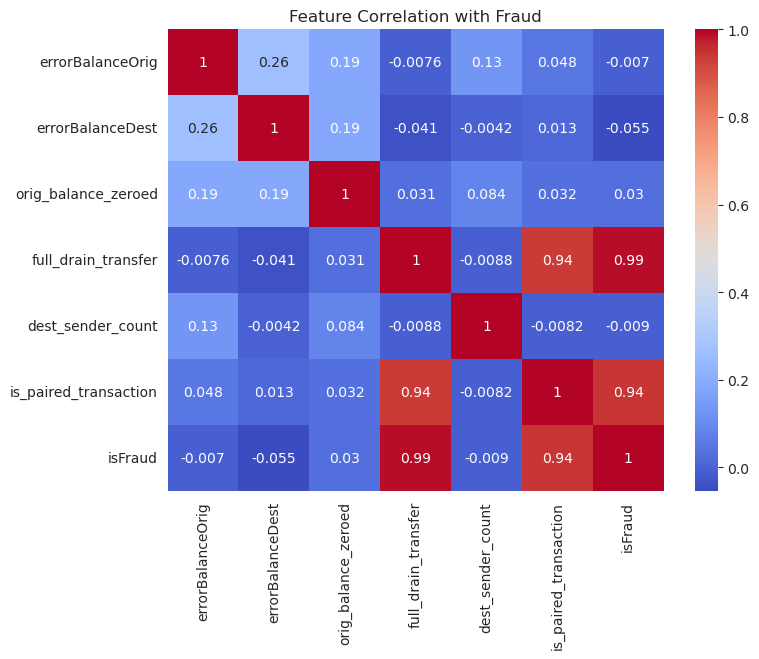

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(data[['errorBalanceOrig','errorBalanceDest','orig_balance_zeroed',
                   'full_drain_transfer','dest_sender_count','is_paired_transaction',
                   'isFraud']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Fraud')
plt.show()

### Fraud Coverage of the Strongest Indicator

The chart below illustrates how much of all fraud in the dataset is captured by the strongest engineered feature, the matched transaction pair indicator, showing the proportion of fraud cases caught versus missed.

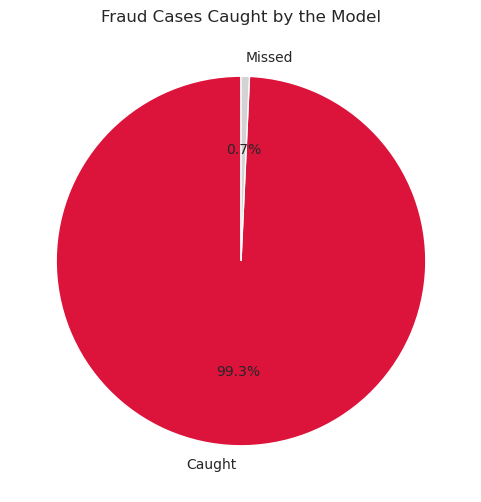

In [19]:
caught = data[(data['isFraud'] == 1) & (data['is_paired_transaction'] == 1)].shape[0]
missed = data[(data['isFraud'] == 1) & (data['is_paired_transaction'] == 0)].shape[0]

plt.figure(figsize=(6,6))
plt.pie([caught, missed], labels=['Caught', 'Missed'], colors=['crimson', 'lightgrey'],
        autopct='%1.1f%%', startangle=90)
plt.title('Fraud Cases Caught by the Model')
plt.show()

## Conclusion

This notebook explored the PaySim mobile money transaction dataset to understand the structure and characteristics of fraudulent transactions, ahead of building a predictive model.

**Class imbalance:** Fraudulent transactions make up only 0.13% of the dataset, confirming that accuracy is not a suitable evaluation metric for this problem. Precision, recall, F1-score, and PR-AUC will be used instead once modelling begins.

**Transaction type:** Fraud occurs exclusively within TRANSFER and CASH_OUT transactions. No fraud cases were found in PAYMENT, CASH_IN, or DEBIT transactions, meaning feature engineering and model attention were concentrated on these two transaction types.

**Balance behaviour:** Fraudulent transactions consistently drain the sender's account completely and exactly, the amount withdrawn matches the account's full prior balance, leaving a resulting balance of zero. This full-drain pattern (`full_drain_transfer`) is present in the large majority of fraud cases, though it can also occur in legitimate full withdrawals, so it is not sufficient as a standalone indicator.

**Destination account behaviour:** The receiving account's balance frequently does not increase as expected following a fraudulent transaction (`errorBalanceDest`), indicating a mismatch between what leaves the sender's account and what appears to arrive at the destination. Additionally, destination accounts involved in fraud tend to have fewer distinct historical senders on average (`dest_sender_count`) than legitimate destination accounts, suggesting fraud-linked accounts are often used once rather than repeatedly, unlike established, reused legitimate accounts.

**Paired transaction pattern:** The strongest signal identified was a matched pair of transactions, a TRANSFER and a CASH_OUT sharing an identical amount at the same simulation step. This pattern (`is_paired_transaction`) is present in 99.27% of all fraud cases, and 90% of transactions matching this pattern are confirmed fraud. This reflects how fraud was constructed within the PaySim simulator itself, funds moved into an intermediate account and immediately cashed out, rather than a directly observed real-world fraud mechanism, and this should be considered when assessing how well these findings would generalise beyond this simulated dataset.

**Summary:** The exploratory analysis identified a clear, learnable pattern behind fraudulent transactions in this dataset, concentrated in TRANSFER and CASH_OUT types, characterised by complete account drains, destination balance mismatches, and matched transaction pairs. These findings directly informed the feature set carried forward into model development.